# Optional Lab: 特征工程与多项式回归

![](../work/images/C1_W2_Lab07_FeatureEngLecture.PNG)


## 目标
在本实验中，你将：
- 探索特征工程和多项式回归，这使你能够使用线性回归的机制来拟合非常复杂甚至非常非线性的函数。


## 工具
你将使用先前实验中开发的函数以及 matplotlib 和 NumPy。

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from lab_utils_multi import zscore_normalize_features, run_gradient_descent_feng
np.set_printoptions(precision=2)  # reduced display precision on numpy arrays

<a name='FeatureEng'></a>
# 特征工程与多项式回归概述

线性回归开箱即用，提供了一种构建以下形式模型的方法：
$$f_{\mathbf{w},b} = w_0x_0 + w_1x_1+ ... + w_{n-1}x_{n-1} + b \tag{1}$$ 
如果你的特征/数据是非线性的或者是特征的组合呢？例如，房价与居住面积往往不是线性关系，而是对非常小或非常大的房子进行惩罚，从而产生上面图形中所示的曲线。我们如何使用线性回归的机制来拟合这条曲线呢？回想一下，我们拥有的“机制”是能够修改（1）中的参数$\mathbf{w}$、$\mathbf{b}$，以使方程“拟合”训练数据。然而，无论如何调整（1）中的$\mathbf{w}$、$\mathbf{b}$，都无法实现对非线性曲线的拟合。


<a name='PolynomialFeatures'></a>
## 多项式特征
上面我们考虑了数据是非线性的情况。让我们尝试使用目前所知的知识来拟合一条非线性曲线。我们将从一个简单的二次方程开始：$y = 1+x^2$。

你熟悉我们正在使用的所有例程。它们可以在 lab_utils.py 文件中找到以供查看。我们将使用[`np.c_[..]`](https://numpy.org/doc/stable/reference/generated/numpy.c_.html)，这是一个 NumPy 例程，用于沿列边界进行拼接。

Iteration         0, Cost: 1.65756e+03
Iteration       100, Cost: 6.94549e+02
Iteration       200, Cost: 5.88475e+02
Iteration       300, Cost: 5.26414e+02
Iteration       400, Cost: 4.90103e+02
Iteration       500, Cost: 4.68858e+02
Iteration       600, Cost: 4.56428e+02
Iteration       700, Cost: 4.49155e+02
Iteration       800, Cost: 4.44900e+02
Iteration       900, Cost: 4.42411e+02
w,b found by gradient descent: w: [18.7], b: -52.0834


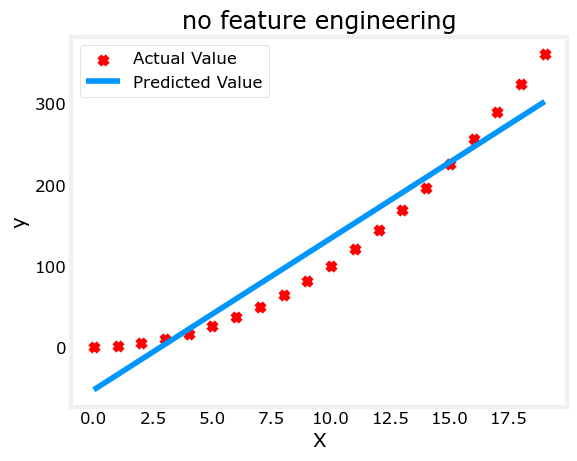

In [26]:
# create target data
x = np.arange(0, 20, 1)
y = 1 + x**2
X = x.reshape(-1, 1)

model_w,model_b = run_gradient_descent_feng(X,y,iterations=1000, alpha = 1e-2)

plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("no feature engineering")
plt.plot(x,X@model_w + model_b, label="Predicted Value");  plt.xlabel("X"); plt.ylabel("y"); plt.legend(); plt.show()

嗯，正如预期的那样，不是很合适。所需要的是类似于$y = w_0x_0^2 + b$的东西，或者一个**多项式特征**。为了实现这一点，你可以修改*输入数据*以*设计*所需的特征。如果你将原始数据替换为对$x$值进行平方后的版本，那么你就可以得到$y = w_0x_0^2 + b$。让我们试试。在下面将`X`替换为`X**2`：

In [27]:
# create target data
x = np.arange(0, 20, 1)
y = 1 + x**2

# Engineer features 
X = x**2      #<-- added engineered feature

Iteration         0, Cost: 7.32922e+03
Iteration      1000, Cost: 2.24844e-01
Iteration      2000, Cost: 2.22795e-01
Iteration      3000, Cost: 2.20764e-01
Iteration      4000, Cost: 2.18752e-01
Iteration      5000, Cost: 2.16758e-01
Iteration      6000, Cost: 2.14782e-01
Iteration      7000, Cost: 2.12824e-01
Iteration      8000, Cost: 2.10884e-01
Iteration      9000, Cost: 2.08962e-01
w,b found by gradient descent: w: [1.], b: 0.0490


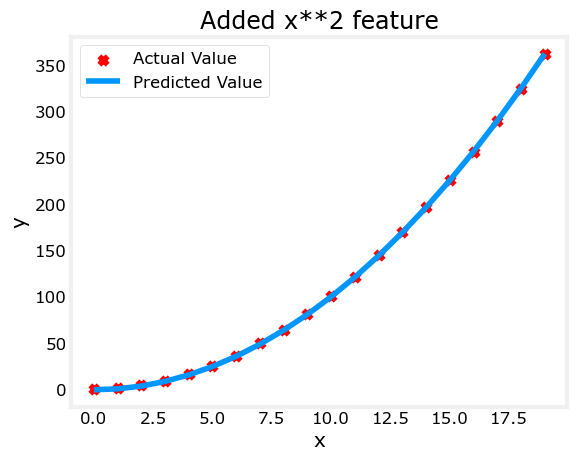

In [28]:
X = X.reshape(-1, 1)  #X should be a 2-D Matrix
model_w,model_b = run_gradient_descent_feng(X, y, iterations=10000, alpha = 1e-5)

plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("Added x**2 feature")
plt.plot(x, np.dot(X,model_w) + model_b, label="Predicted Value"); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()

太棒了！近乎完美的拟合。请注意图正上方打印的$\mathbf{w}$和$b$的值：`通过梯度下降找到的$w$、$b$：$w$：[1.]，$b$：0.0490`。梯度下降将我们的$\mathbf{w}$、$b$的初始值修改为(1.0,0.049)，即模型为$y = 1*x_0^2 + 0.049$，非常接近我们的目标$y = 1*x_0^2 + 1$。如果你运行的时间更长，它可能会更匹配。

### 选择特征
<a name='GDF'></a>
上面，我们知道需要一个$x^2$项。但并不总是很明显需要哪些特征。可以添加各种潜在特征来尝试找到最有用的。例如，如果我们尝试：$y = w_0x_0 + w_1x_1^2 + w_2x_2^3 + b$会怎样？
运行下面的单元格。

In [29]:
# create target data
x = np.arange(0, 20, 1)
y = x**2

# engineer features .
X = np.c_[x, x**2, x**3]   #<-- added engineered feature

Iteration         0, Cost: 1.14029e+03
Iteration      1000, Cost: 3.28539e+02
Iteration      2000, Cost: 2.80443e+02
Iteration      3000, Cost: 2.39389e+02
Iteration      4000, Cost: 2.04344e+02
Iteration      5000, Cost: 1.74430e+02
Iteration      6000, Cost: 1.48896e+02
Iteration      7000, Cost: 1.27100e+02
Iteration      8000, Cost: 1.08495e+02
Iteration      9000, Cost: 9.26132e+01
w,b found by gradient descent: w: [0.08 0.54 0.03], b: 0.0106


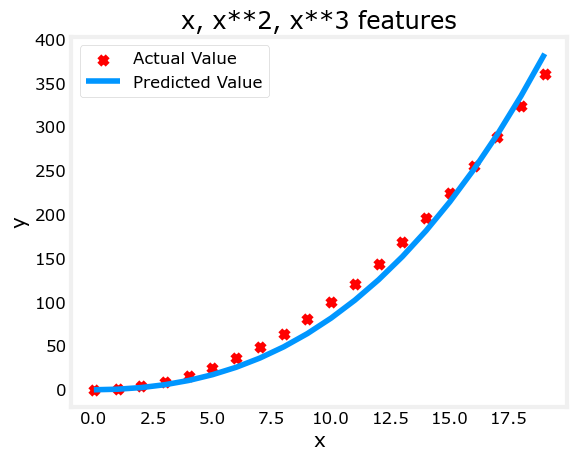

In [30]:
model_w,model_b = run_gradient_descent_feng(X, y, iterations=10000, alpha=1e-7)

plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("x, x**2, x**3 features")
plt.plot(x, X@model_w + model_b, label="Predicted Value"); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()

注意向量 $\mathbf{w}$ 的值，`[0.08 0.54 0.03]`，并且 b 是 `0.0106`。这意味着经过拟合/训练后的模型是：
$$0.08x + 0.54x^2 + 0.03x^3 + 0.0106$$
梯度下降通过增加相对于其他项的 $w_1$ 项，强调了最适合 $x^2$ 数据的数据。如果你运行很长时间，它将继续减少其他项的影响。
>梯度下降通过强调其相关参数为我们选择“正确”的特征。
让我们回顾一下这个想法：
- 最初，特征被重新缩放，以便它们彼此可比。
- 较小的权重值意味着不太重要/正确的特征，在极端情况下，当权重变为零或非常接近零时，相关特征在将模型拟合到数据时很有用。
- 如上所述，在拟合后，与 $x^2$ 特征相关的权重比与 $x$ 或 $x^3$ 的权重大得多，因为它在拟合数据时最有用。

### 另一种视角
上文提到，多项式特征是根据它们与目标数据的匹配程度来选择的。另一种思考方式是注意到，一旦我们创建了新特征，我们仍然在使用线性回归。鉴于此，最佳特征将相对于目标是线性的。通过一个例子可以最好地理解这一点。

In [31]:
# create target data
x = np.arange(0, 20, 1)
y = x**2

# engineer features .
X = np.c_[x, x**2, x**3]   #<-- added engineered feature
X_features = ['x','x^2','x^3']

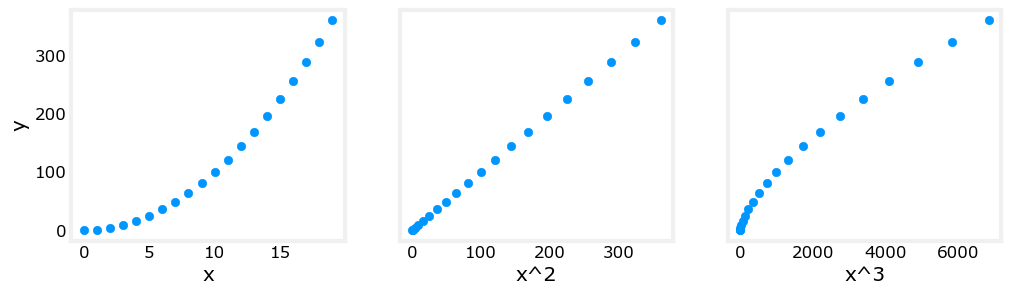

In [32]:
fig,ax=plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X[:,i],y)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("y")
plt.show()

上文表明，与目标值$y$相对应的$x^2$特征是线性的。然后，线性回归可以很容易地使用该特征生成一个模型。

### 特征缩放
正如上一个实验中所描述的，如果数据集具有明显不同尺度的特征，那么应该应用特征缩放来加速梯度下降。在上面的例子中，有$x$、$x^2$和$x^3$，它们自然会有非常不同的尺度。让我们将 Z-score 标准化应用于我们的例子。

In [33]:
# create target data
x = np.arange(0,20,1)
X = np.c_[x, x**2, x**3]
print(f"Peak to Peak range by column in Raw        X:{np.ptp(X,axis=0)}")

# add mean_normalization 
X = zscore_normalize_features(X)     
print(f"Peak to Peak range by column in Normalized X:{np.ptp(X,axis=0)}")

Peak to Peak range by column in Raw        X:[  19  361 6859]
Peak to Peak range by column in Normalized X:[3.3  3.18 3.28]


现在我们可以用一个更激进的 alpha 值再试一次：

Iteration         0, Cost: 9.49063e+03
Iteration     10000, Cost: 1.64790e+00
Iteration     20000, Cost: 9.36329e-01
Iteration     30000, Cost: 9.12417e-01
Iteration     40000, Cost: 9.11614e-01
Iteration     50000, Cost: 9.11587e-01
Iteration     60000, Cost: 9.11586e-01
Iteration     70000, Cost: 9.11586e-01
Iteration     80000, Cost: 9.11586e-01
Iteration     90000, Cost: 9.11586e-01
w,b found by gradient descent: w: [-66.39 160.26  19.71], b: 123.5000


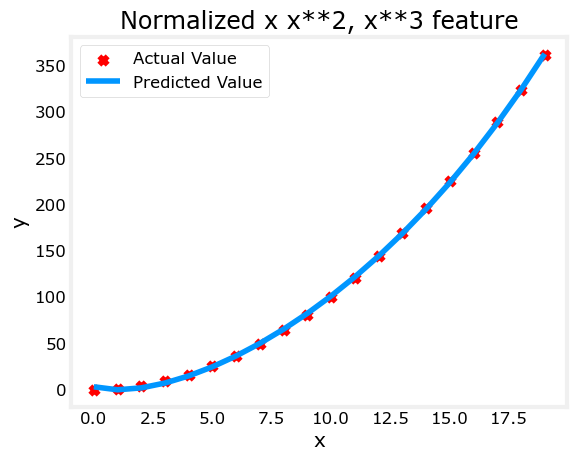

In [34]:
x = np.arange(0,20,1)
y = x**2

X = np.c_[x, x**1.4, x**4]
X = zscore_normalize_features(X) 

model_w, model_b = run_gradient_descent_feng(X, y, iterations=100000, alpha=1e-1)

plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("Normalized x x**2, x**3 feature")
plt.plot(x,X@model_w + model_b, label="Predicted Value"); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()

特征缩放使这个收敛得更快。  
再次注意$\mathbf{w}$的值。$w_1$项，即$x^2$项是最被强调的。梯度下降几乎消除了$x^3$项。

### 复杂函数
借助特征工程，即使是非常复杂的函数也可以进行建模：

Iteration         0, Cost: 2.20188e-01
Iteration    100000, Cost: 1.70074e-02
Iteration    200000, Cost: 1.27603e-02
Iteration    300000, Cost: 9.73032e-03
Iteration    400000, Cost: 7.56440e-03
Iteration    500000, Cost: 6.01412e-03
Iteration    600000, Cost: 4.90251e-03
Iteration    700000, Cost: 4.10351e-03
Iteration    800000, Cost: 3.52730e-03
Iteration    900000, Cost: 3.10989e-03
w,b found by gradient descent: w: [ -1.34 -10.    24.78   5.96 -12.49 -16.26  -9.51   0.59   8.7   11.94
   9.27   0.79 -12.82], b: -0.0073


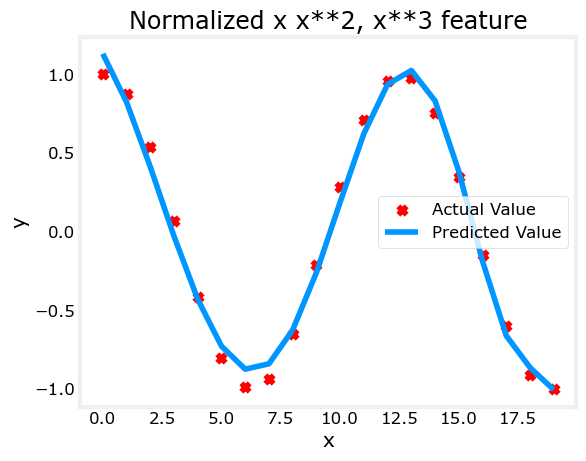

In [35]:
x = np.arange(0,20,1)
y = np.cos(x/2)

X = np.c_[x, x**2, x**3,x**4, x**5, x**6, x**7, x**8, x**9, x**10, x**11, x**12, x**13]
X = zscore_normalize_features(X) 

model_w,model_b = run_gradient_descent_feng(X, y, iterations=1000000, alpha = 1e-1)

plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("Normalized x x**2, x**3 feature")
plt.plot(x,X@model_w + model_b, label="Predicted Value"); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()



## 恭喜！
在这个实验中，你：
- 学习了线性回归如何使用特征工程来对复杂甚至高度非线性的函数进行建模。
- 认识到在进行特征工程时应用特征缩放非常重要。